## Installing packages and importing libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Modelling 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression,Lasso,Ridge
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error    
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')


### Import the csv file data as pandas Dataframe

In [10]:
df=pd.read_csv('data/stud.csv')
df.sample(5)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
56,female,group E,associate's degree,standard,completed,82,85,86
699,male,group C,high school,free/reduced,none,66,66,59
647,female,group E,high school,free/reduced,none,64,62,68
745,male,group D,associate's degree,standard,none,72,79,74
295,male,group B,associate's degree,free/reduced,none,67,62,60


In [11]:
X=df.drop(columns=['math_score'])
y=df['math_score']


In [12]:
# Create column transformer with 3 types of transformers
num_cols=X.select_dtypes(include=np.number).columns
cat_cols=X.select_dtypes(exclude=np.number).columns

numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder(handle_unknown='ignore',drop='first')
le_transformer=LabelEncoder()

preprocessor=ColumnTransformer(
    [      
        ("OneHotEncoder",oh_transformer,cat_cols),
        ("StandardScaler",numeric_transformer,num_cols)    
    ]
)


In [13]:
X=preprocessor.fit_transform(X)
X

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 14))

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((800, 14), (200, 14), (800,), (200,))

### Create an evaluation function to give all metrics after model training

In [15]:
def evaluate_model(true,pred):
    mae=mean_absolute_error(true,pred)
    mse=mean_squared_error(true,pred)
    rmse=np.sqrt(mse)
    r2=r2_score(true,pred)
    return mae,mse,rmse,r2

In [18]:
models={
    "Linear Regression":LinearRegression(),
    "lasso":Lasso(),
    "Ridge":Ridge(),
    "Random Forest":RandomForestRegressor(),
    "AdaBoost":AdaBoostRegressor(),
    "Gradient Boosting":GradientBoostingRegressor(),
    "CatBoost":CatBoostRegressor(verbose=0),
    "XGBoost":XGBRegressor(verbose=0),
    "Support Vector Regressor":SVR(),
    "Decision Tree":DecisionTreeRegressor()
}

model_list=[]
r2_list=[]

for name,model in models.items():
    model=model
    model.fit(X_train,y_train)

    #Make predictions
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)


    #Evaluate model train and test dataset

    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)


    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(name)
    model_list.append(name)

    print("Model performance for training set:")
    print("Root mean squared error {:.4f}".format(model_train_rmse))
    print("Mean Absolute error {:.4f}".format(model_train_mae))
    print("R-squared {:.4f}".format(model_train_r2))
    
    print("\n")
    print("Model performance for test set:")    
    print("Root mean squared error {:.4f}".format(model_test_rmse))
    print("Mean Absolute error {:.4f}".format(model_test_mae))
    print("R-squared {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    print("=====================================================")

Linear Regression
Model performance for training set:
Root mean squared error 5.3231
Mean Absolute error 4.2667
R-squared 0.8743


Model performance for test set:
Root mean squared error 5.3940
Mean Absolute error 4.2148
R-squared 0.8804
lasso
Model performance for training set:
Root mean squared error 6.5938
Mean Absolute error 5.2063
R-squared 0.8071


Model performance for test set:
Root mean squared error 6.5197
Mean Absolute error 5.1579
R-squared 0.8253
Ridge
Model performance for training set:
Root mean squared error 5.3235
Mean Absolute error 4.2650
R-squared 0.8743


Model performance for test set:
Root mean squared error 5.3936
Mean Absolute error 4.2125
R-squared 0.8805
Random Forest
Model performance for training set:
Root mean squared error 2.2673
Mean Absolute error 1.8113
R-squared 0.9772


Model performance for test set:
Root mean squared error 6.0034
Mean Absolute error 4.6473
R-squared 0.8519
AdaBoost
Model performance for training set:
Root mean squared error 5.7742


In [19]:
Results=pd.DataFrame({"Model":model_list,"R2_score":r2_list}).sort_values(by="R2_score",ascending=False)
Results

,Model,R2_score
2,Ridge,0.880451
0,Linear Regression,0.880433
5,Gradient Boosting,0.872376
4,AdaBoost,0.852671
3,Random Forest,0.851892
6,CatBoost,0.849801
1,lasso,0.825320
7,XGBoost,0.825046
9,Decision Tree,0.750574
8,Support Vector Regressor,0.713014


In [20]:
# Linear Regression and Ridge regression are performing well with R2 score of 0.86 and 0.85 respectively. We can further tune the hyperparameters of these models to improve the performance.
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(X_train,y_train)
y_test_pred=lin_model.predict(X_test)
score=evaluate_model(y_test,y_test_pred)
print("Model performance for test set:")    
print("Root mean squared error {:.4f}".format(score[2]))    
print("Mean Absolute error {:.4f}".format(score[0]))
print("R-squared {:.4f}".format(score[3]))
print("=====================================================")

Model performance for test set:
Root mean squared error 5.3940
Mean Absolute error 4.2148
R-squared 0.8804


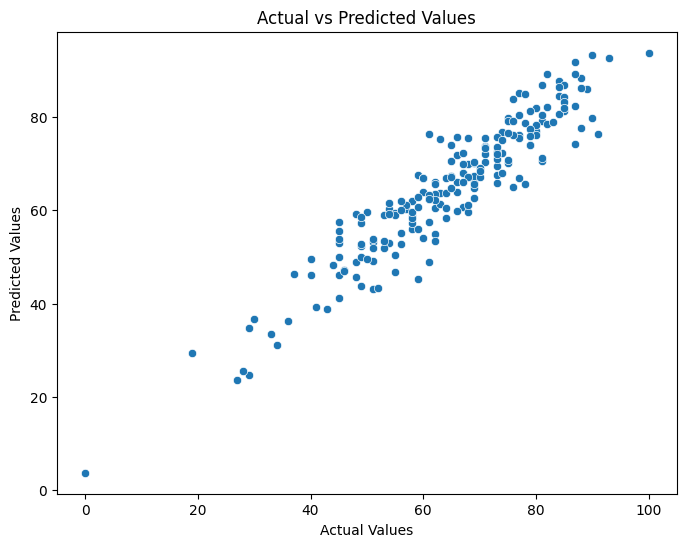

In [21]:
# Plot the Actual and Predicted values
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=y_test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

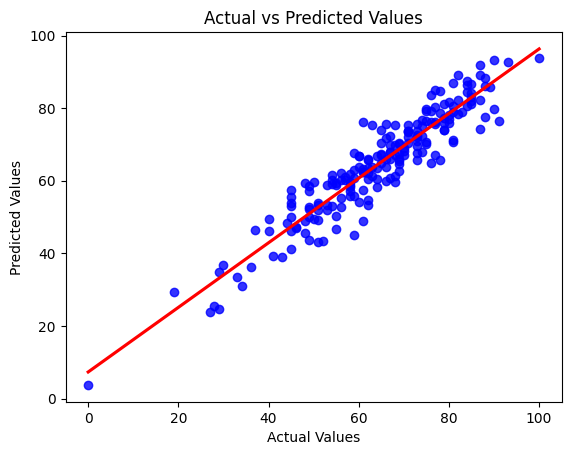

In [22]:
sns.regplot(x=y_test,y=y_test_pred,ci=None,scatter_kws={"color":"blue"},line_kws={"color":"red"})
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()